# TRL4 – Transporte D&R (Binder / JupyterLab Web)
Este notebook está listo para ejecutarse en **JupyterLab Web (Binder)** o en JupyterLab local.

## Estructura del proyecto
- `data/` contiene los CSV
- `notebooks/` contiene este notebook

**Cómo ejecutar:** abrir este notebook y usar `Run → Run All Cells`.


In [5]:
# 1) Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingRegressor

from pathlib import Path
DATA = Path("..") / "data"   # notebook está en notebooks/
print("DATA:", DATA.resolve())


DATA: /home/data


In [6]:
# 2) Cargar datos (Binder: archivos dentro de /data)
import pandas as pd

drivers = pd.read_csv("data/drivers.csv")
trips   = pd.read_csv("data/trips.csv", parse_dates=["date"])
orders  = pd.read_csv("data/orders_routing.csv")

print("Drivers:", drivers.shape)
print("Trips:", trips.shape)
print("Orders:", orders.shape)
drivers.head()


Drivers: (40, 5)
Trips: (3194, 16)
Orders: (26, 5)


,driver_id,experience_years,incidents_last_year,overtime_hours_month,avg_rest_hours_day
0,D001,7,0,34,7.0
1,D002,20,0,36,6.3
2,D003,15,0,13,6.7
3,D004,11,1,2,7.3
4,D005,8,0,0,8.5


## Módulo 1 — Regresión: predicción de consumo de combustible

In [7]:
features = ["distance_km", "load_ton", "traffic_index", "elevation_gain_m", "avg_speed_kmh"]
target = "fuel_liters"

missing_cols = [c for c in features + [target] if c not in trips.columns]
if missing_cols:
    raise ValueError(f"En trips.csv faltan columnas: {missing_cols}")

X = trips[features].copy()
y = trips[target].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"MAE: {mae:.2f} L")
print(f"R^2: {r2:.3f}")


MAE: 22.24 L
R^2: 0.928


distance_km         0.972929
load_ton            0.017693
traffic_index       0.005513
avg_speed_kmh       0.002241
elevation_gain_m    0.001625
dtype: float64

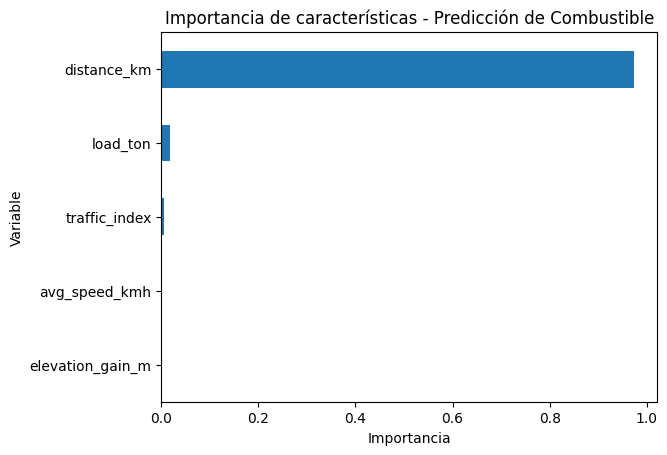

In [8]:
# Importancia de variables + gráfico
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
display(importances)

plt.figure()
importances.sort_values().plot(kind="barh")
plt.title("Importancia de características - Predicción de Combustible")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()


In [9]:
# Recomendación simple: comparar alternativas
def estimate_fuel(distance_km, load_ton, traffic_index, elevation_gain_m, avg_speed_kmh):
    x = pd.DataFrame([{
        "distance_km": distance_km,
        "load_ton": load_ton,
        "traffic_index": traffic_index,
        "elevation_gain_m": elevation_gain_m,
        "avg_speed_kmh": avg_speed_kmh
    }])
    return float(model.predict(x)[0])

alt1 = estimate_fuel(distance_km=650, load_ton=15, traffic_index=0.5, elevation_gain_m=300, avg_speed_kmh=55)
alt2 = estimate_fuel(distance_km=590, load_ton=15, traffic_index=0.7, elevation_gain_m=480, avg_speed_kmh=48)

print("Consumo estimado (Alt1):", round(alt1, 1), "L")
print("Consumo estimado (Alt2):", round(alt2, 1), "L")
print("Recomendación:", "Alt2" if alt2 < alt1 else "Alt1")


Consumo estimado (Alt1): 194.2 L
Consumo estimado (Alt2): 188.0 L
Recomendación: Alt2


## Módulo 2 — K-means: segmentación de conductores

In [10]:
kcols = ["experience_years", "incidents_last_year", "overtime_hours_month", "avg_rest_hours_day"]
missing_k = [c for c in kcols if c not in drivers.columns]
if missing_k:
    raise ValueError(f"En drivers.csv faltan columnas: {missing_k}")

kdata = drivers[kcols].copy()

scaler = StandardScaler()
kdata_scaled = scaler.fit_transform(kdata)

kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)
drivers["cluster"] = kmeans.fit_predict(kdata_scaled)

cluster_summary = drivers.groupby("cluster")[kcols].mean().round(2)
display(cluster_summary)


,experience_years,incidents_last_year,overtime_hours_month,avg_rest_hours_day
cluster,,,,
0,6.00,0.23,30.38,7.34
1,17.36,0.14,24.50,6.76
2,8.38,0.46,7.46,8.10


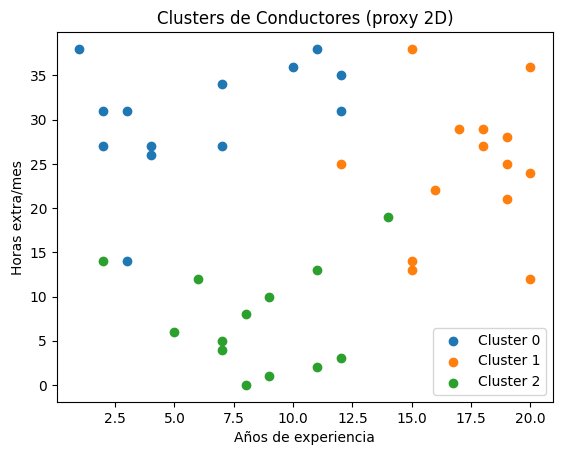

In [11]:
# Scatter proxy 2D
plt.figure()
for c in sorted(drivers["cluster"].unique()):
    subset = drivers[drivers["cluster"] == c]
    plt.scatter(subset["experience_years"], subset["overtime_hours_month"], label=f"Cluster {c}")
plt.xlabel("Años de experiencia")
plt.ylabel("Horas extra/mes")
plt.title("Clusters de Conductores (proxy 2D)")
plt.legend()
plt.show()


## Módulo 3 — Optimización de rutas: greedy + 2-opt

In [12]:
def dist(a, b):
    return float(np.hypot(a[0]-b[0], a[1]-b[1]))

def total_route_length(coords):
    return sum(dist(coords[i], coords[i+1]) for i in range(len(coords)-1))

CAPACITY_TON = 12.0

orders_ = orders.copy().fillna(0.0)
min_cols = ["order_id", "x", "y", "demand_ton", "service_min"]
missing_o = [c for c in min_cols if c not in orders_.columns]
if missing_o:
    raise ValueError(f"En orders_routing.csv faltan columnas: {missing_o}")

clients = orders_[orders_["order_id"] != "DEPOT"].reset_index(drop=True)

depot = (0.0, 0.0)
coords = [(row.x, row.y) for _, row in clients.iterrows()]
demands = clients["demand_ton"].to_numpy()

unvisited = set(range(len(coords)))
routes = []

while unvisited:
    cap = CAPACITY_TON
    route = []
    current = depot
    while True:
        candidates = [i for i in list(unvisited) if demands[i] <= cap]
        if not candidates:
            break
        nearest = min(candidates, key=lambda i: dist(current, coords[i]))
        route.append(nearest)
        cap -= demands[nearest]
        current = coords[nearest]
        unvisited.remove(nearest)
    routes.append(route)

def two_opt(coords_route):
    improved = True
    while improved:
        improved = False
        for i in range(1, len(coords_route)-2):
            for j in range(i+1, len(coords_route)):
                if j - i == 1:
                    continue
                new_route = coords_route[:]
                new_route[i:j] = reversed(coords_route[i:j])
                if total_route_length(new_route) < total_route_length(coords_route):
                    coords_route = new_route
                    improved = True
    return coords_route

optimized_routes = []
for route in routes:
    crd = [depot] + [coords[i] for i in route] + [depot]
    optimized_routes.append(two_opt(crd))

total_km = sum(total_route_length(r) for r in optimized_routes)
print(f"Rutas generadas: {len(optimized_routes)}")
print(f"Distancia total (aprox): {total_km:.1f} km")


Rutas generadas: 3
Distancia total (aprox): 492.1 km


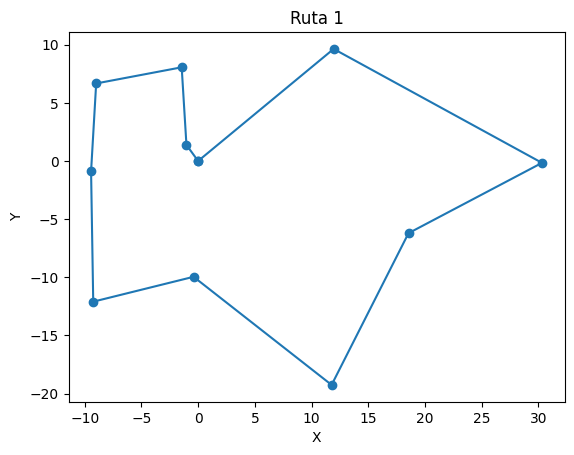

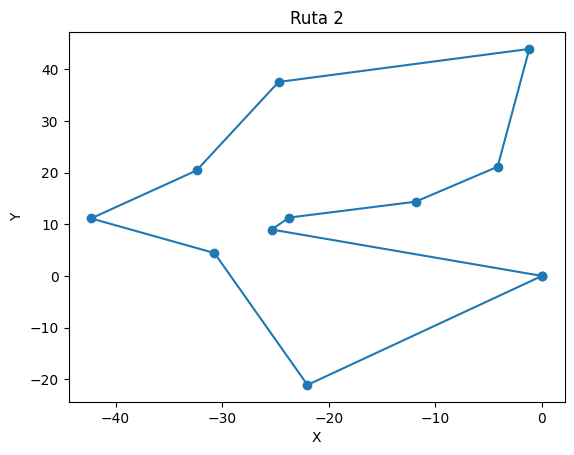

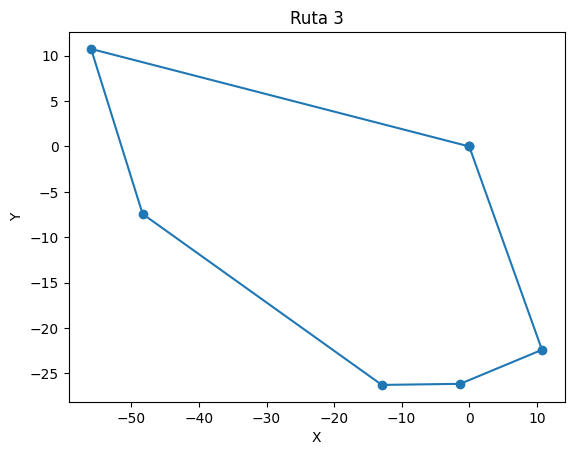

In [13]:
# Graficar rutas
for idx, r in enumerate(optimized_routes, start=1):
    xs = [p[0] for p in r]
    ys = [p[1] for p in r]
    plt.figure()
    plt.plot(xs, ys, marker='o')
    plt.title(f"Ruta {idx}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()


## Módulo 4 — Monte Carlo: tiempos de entrega

In [14]:
np.random.seed(123)

avg_speed_kmh = 45.0
traffic_cv = 0.25
service_mean_min = orders_.loc[orders_["order_id"] != "DEPOT", "service_min"].mean()

def simulate_route_minutes(route_coords, trials=1000):
    base_dist_km = total_route_length(route_coords)
    base_time_min = (base_dist_km / avg_speed_kmh) * 60.0 + service_mean_min * (len(route_coords)-2)
    traffic_multiplier = np.random.lognormal(mean=0, sigma=traffic_cv, size=trials)
    return base_time_min * traffic_multiplier

all_times = [simulate_route_minutes(r, trials=2000) for r in optimized_routes]

kpis = []
for idx, times in enumerate(all_times, start=1):
    kpis.append({
        "ruta": idx,
        "P50_min": round(np.percentile(times, 50), 1),
        "P80_min": round(np.percentile(times, 80), 1),
        "P95_min": round(np.percentile(times, 95), 1),
    })
kpis_df = pd.DataFrame(kpis)
display(kpis_df)


,ruta,P50_min,P80_min,P95_min
0,1,389.7,480.3,579.1
1,2,500.1,611.6,758.1
2,3,338.0,413.4,507.7


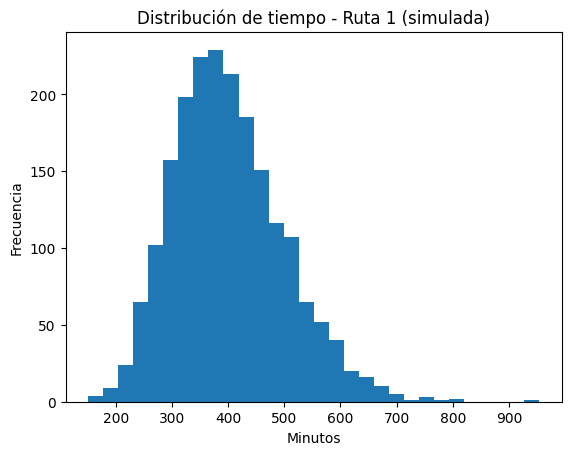

In [15]:
plt.figure()
plt.hist(all_times[0], bins=30)
plt.title("Distribución de tiempo - Ruta 1 (simulada)")
plt.xlabel("Minutos")
plt.ylabel("Frecuencia")
plt.show()
